## 1.Загрузка показателей из Worldbank
Загружаем демографические и социальные показатели+базоваые. Используем worldbank api

In [1]:
import wbgapi as wb
import pandas as pd

indicator = 'SP.POP.TOTL'
years = range(1960, 2021)

# 'all' = все страны
df = wb.data.DataFrame(indicator, economy='all', time=years)

df = df.reset_index()
print(df.head())

  economy       YR1960       YR1961       YR1962       YR1963       YR1964  \
0     ABW      54922.0      55578.0      56320.0      57002.0      57619.0   
1     AFE  130075728.0  133534923.0  137171659.0  140945536.0  144904094.0   
2     AFG    9035043.0    9214083.0    9404406.0    9604487.0    9814318.0   
3     AFW   97630925.0   99706674.0  101854756.0  104089175.0  106388440.0   
4     AGO    5231654.0    5301583.0    5354310.0    5408320.0    5464187.0   

        YR1965       YR1966       YR1967       YR1968  ...       YR2011  \
0      58190.0      58694.0      58990.0      59069.0  ...     102591.0   
1  149033472.0  153281203.0  157704381.0  162329396.0  ...  544737983.0   
2   10036008.0   10266395.0   10505959.0   10756922.0  ...   29347708.0   
3  108772632.0  111246953.0  113795019.0  116444636.0  ...  374790143.0   
4    5521981.0    5581386.0    5641807.0    5702699.0  ...   24218352.0   

        YR2012       YR2013       YR2014       YR2015       YR2016  \
0     1041

In [6]:
import wbgapi as wb
import pandas as pd

ind = list(wb.series.list())
df_ind = pd.DataFrame(ind)

print(df_ind.head(5))
print(len(df_ind))

                   id                                              value
0   AG.CON.FERT.PT.ZS  Fertilizer consumption (% of fertilizer produc...
1      AG.CON.FERT.ZS  Fertilizer consumption (kilograms per hectare ...
2      AG.LND.AGRI.K2                         Agricultural land (sq. km)
3      AG.LND.AGRI.ZS                 Agricultural land (% of land area)
4      AG.LND.ARBL.HA                             Arable land (hectares)
5   AG.LND.ARBL.HA.PC                  Arable land (hectares per person)
6      AG.LND.ARBL.ZS                       Arable land (% of land area)
7      AG.LND.CREL.HA            Land under cereal production (hectares)
8      AG.LND.CROP.ZS                Permanent cropland (% of land area)
9   AG.LND.EL5M.RU.K2  Rural land area where elevation is below 5 met...
10  AG.LND.EL5M.RU.ZS  Rural land area where elevation is below 5 met...
11  AG.LND.EL5M.UR.K2  Urban land area where elevation is below 5 met...
12  AG.LND.EL5M.UR.ZS  Urban land area where elevat

In [9]:
import wbgapi as wb
import pandas as pd

ind = list(wb.series.list())
df = pd.DataFrame(ind)

col = 'value'  # вместо 'name'

keywords = [
    'population', 'fertility', 'birth', 'death', 'mortality',
    'life expectancy', 'age', 'dependency', 'migration',
    'urban', 'rural'
]

pattern = '|'.join(keywords)

df_demo = df[df[col].str.lower().str.contains(pattern)]
print(df_demo)
print(len(df_demo))


                     id                                              value
9     AG.LND.EL5M.RU.K2  Rural land area where elevation is below 5 met...
10    AG.LND.EL5M.RU.ZS  Rural land area where elevation is below 5 met...
11    AG.LND.EL5M.UR.K2  Urban land area where elevation is below 5 met...
12    AG.LND.EL5M.UR.ZS  Urban land area where elevation is below 5 met...
17       AG.LND.PRCP.MM       Average precipitation in depth (mm per year)
...                 ...                                                ...
1416        SP.UWT.TFRT  Unmet need for contraception (% of married wom...
1429  TM.TAX.MANF.BC.ZS        Binding coverage, manufactured products (%)
1435  TM.TAX.MRCH.BC.ZS                 Binding coverage, all products (%)
1441  TM.TAX.TCOM.BC.ZS             Binding coverage, primary products (%)
1510        VC.BTL.DETH           Battle-related deaths (number of people)

[489 rows x 2 columns]
489


In [11]:
import pandas as pd
df_health = pd.DataFrame(list(wb.series.list(topic=16)))
df_social = pd.DataFrame(list(wb.series.list(topic=15)))

df_topics = pd.concat([df_health, df_social]).drop_duplicates('id')

                   id                                              value
13        SP.URB.TOTL                                   Urban population
14  SP.URB.TOTL.IN.ZS           Urban population (% of total population)
15        SP.URB.GROW                 Urban population growth (annual %)
0         SP.ADO.TFRT  Adolescent fertility rate (births per 1,000 wo...
18  SP.DYN.LE00.FE.IN           Life expectancy at birth, female (years)
19  SP.DYN.LE00.MA.IN             Life expectancy at birth, male (years)
6


In [12]:
print(df_topics)
print(len(df_topics))

                        id                                              value
0        EG.ELC.ACCS.UR.ZS  Access to electricity, urban (% of urban popul...
1           SH.STA.TRAF.P5  Mortality caused by road traffic injury (per 1...
2        EN.ATM.PM25.MC.M3  PM2.5 air pollution, mean annual exposure (mic...
3        EN.ATM.PM25.MC.ZS  PM2.5 air pollution, population exposed to lev...
4              EN.POP.DNST  Population density (people per sq. km of land ...
5              EN.URB.LCTY                         Population in largest city
6        EN.URB.LCTY.UR.ZS  Population in the largest city (% of urban pop...
7              EN.URB.MCTY  Population in urban agglomerations of more tha...
8        EN.URB.MCTY.TL.ZS  Population in urban agglomerations of more tha...
9        EN.POP.SLUM.UR.ZS  Population living in slums (% of urban populat...
10       AG.LND.TOTL.UR.K2                           Urban land area (sq. km)
11       AG.LND.EL5M.UR.ZS  Urban land area where elevation is b

In [19]:
import wbgapi as wb
import pandas as pd
from tqdm.notebook import tqdm

inds = df_topics['id'].tolist()
all_tables = []

for ind in tqdm(inds):
    df_part = wb.data.DataFrame(ind, economy='all', time='all').reset_index()
    df_part['indicator'] = ind
    if 'year' in df_part.columns:
        key_cols = ['economy', 'year']
    else:
        key_cols = ['economy']
    
    value_cols = [c for c in df_part.columns if c not in key_cols]
    df_part = df_part.rename(columns={c: f"{ind}_{c}" for c in value_cols})
    if 'USA' in df_part.iloc[:, 0].values:
        if len(all_tables) == 0:
            all_tables.append(df_part)
        else:
            all_tables[0] = all_tables[0].merge(df_part, on=df_part.columns[0], how='left')
    else:
        all_tables.append(df_part)



  0%|          | 0/49 [00:00<?, ?it/s]

,economy,EG.ELC.ACCS.UR.ZS_YR1960,EG.ELC.ACCS.UR.ZS_YR1961,EG.ELC.ACCS.UR.ZS_YR1962,EG.ELC.ACCS.UR.ZS_YR1963,EG.ELC.ACCS.UR.ZS_YR1964,EG.ELC.ACCS.UR.ZS_YR1965,EG.ELC.ACCS.UR.ZS_YR1966,EG.ELC.ACCS.UR.ZS_YR1967,EG.ELC.ACCS.UR.ZS_YR1968,...,SL.EMP.VULN.MA.ZS_YR2016,SL.EMP.VULN.MA.ZS_YR2017,SL.EMP.VULN.MA.ZS_YR2018,SL.EMP.VULN.MA.ZS_YR2019,SL.EMP.VULN.MA.ZS_YR2020,SL.EMP.VULN.MA.ZS_YR2021,SL.EMP.VULN.MA.ZS_YR2022,SL.EMP.VULN.MA.ZS_YR2023,SL.EMP.VULN.MA.ZS_YR2024,SL.EMP.VULN.MA.ZS_indicator
0,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SL.EMP.VULN.MA.ZS
1,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.199826,64.304656,64.292049,64.466647,65.244464,65.193823,64.986420,66.448232,NaN,SL.EMP.VULN.MA.ZS
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.730539,77.268806,78.218422,79.309838,80.627456,78.670575,80.000554,79.558901,NaN,SL.EMP.VULN.MA.ZS
3,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,63.244220,62.735685,62.232310,61.575965,62.404344,62.046871,61.996920,61.592681,NaN,SL.EMP.VULN.MA.ZS
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,47.433516,47.774339,48.145114,48.639166,49.293087,48.902322,48.980457,49.330760,NaN,SL.EMP.VULN.MA.ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SL.EMP.VULN.MA.ZS
262,YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,43.470047,44.566984,45.382191,45.899027,46.074490,45.743288,45.580672,45.783968,NaN,SL.EMP.VULN.MA.ZS
263,ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.495234,9.678684,10.389491,10.730693,11.084928,11.615068,11.991002,11.123571,NaN,SL.EMP.VULN.MA.ZS
264,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.399948,66.994310,63.020250,65.360491,65.853861,60.695311,62.425958,62.153116,NaN,SL.EMP.VULN.MA.ZS


In [20]:
import wbgapi as wb
import pandas as pd
from tqdm import tqdm

indicators = {
    'worldbank_age_0_14_share.csv': 'SP.POP.0014.TO.ZS',
    'worldbank_age_65_plus_share.csv': 'SP.POP.65UP.TO.ZS',
    'worldbank_crude_birth_rate.csv': 'SP.DYN.CBRT.IN',
    'worldbank_crude_death_rate.csv': 'SP.DYN.CDRT.IN',
    'worldbank_fertility_rate.csv': 'SP.DYN.TFRT.IN',
    'worldbank_inflation.csv': 'FP.CPI.TOTL.ZG',
    'worldbank_life_expectancy.csv': 'SP.DYN.LE00.IN',
    'worldbank_net_migration.csv': 'SM.POP.NETM',
    'worldbank_population.csv': 'SP.POP.TOTL',
    'worldbank_school_tertiary.csv': 'SE.TER.ENRR',
    'worldbank_under5_mortality.csv': 'SH.DYN.MORT',
    'worldbank_unemployment.csv': 'SL.UEM.TOTL.ZS',
    'worldbank_urban_share.csv': 'SP.URB.TOTL.IN.ZS'
}

for _, ind in tqdm(indicators.items()):
    df_part = wb.data.DataFrame(ind, economy='all', time='all').reset_index()
    df_part['indicator'] = ind
    if 'year' in df_part.columns:
        key_cols = ['economy', 'year']
    else:
        key_cols = ['economy']
    
    value_cols = [c for c in df_part.columns if c not in key_cols]
    df_part = df_part.rename(columns={c: f"{ind}_{c}" for c in value_cols})
    if 'USA' in df_part.iloc[:, 0].values:
        if len(all_tables) == 0:
            all_tables.append(df_part)
        else:
            all_tables[0] = all_tables[0].merge(df_part, on=df_part.columns[0], how='left')
    else:
        all_tables.append(df_part)

100%|██████████| 13/13 [30:02<00:00, 138.62s/it]


### Проверка и merge таблиц

In [27]:
for table in all_tables[1:]:
    print(table.columns)
pd.set_option('display.max_columns', None)

print(", ".join(all_tables[0].columns))

economy, EG.ELC.ACCS.UR.ZS_YR1960, EG.ELC.ACCS.UR.ZS_YR1961, EG.ELC.ACCS.UR.ZS_YR1962, EG.ELC.ACCS.UR.ZS_YR1963, EG.ELC.ACCS.UR.ZS_YR1964, EG.ELC.ACCS.UR.ZS_YR1965, EG.ELC.ACCS.UR.ZS_YR1966, EG.ELC.ACCS.UR.ZS_YR1967, EG.ELC.ACCS.UR.ZS_YR1968, EG.ELC.ACCS.UR.ZS_YR1969, EG.ELC.ACCS.UR.ZS_YR1970, EG.ELC.ACCS.UR.ZS_YR1971, EG.ELC.ACCS.UR.ZS_YR1972, EG.ELC.ACCS.UR.ZS_YR1973, EG.ELC.ACCS.UR.ZS_YR1974, EG.ELC.ACCS.UR.ZS_YR1975, EG.ELC.ACCS.UR.ZS_YR1976, EG.ELC.ACCS.UR.ZS_YR1977, EG.ELC.ACCS.UR.ZS_YR1978, EG.ELC.ACCS.UR.ZS_YR1979, EG.ELC.ACCS.UR.ZS_YR1980, EG.ELC.ACCS.UR.ZS_YR1981, EG.ELC.ACCS.UR.ZS_YR1982, EG.ELC.ACCS.UR.ZS_YR1983, EG.ELC.ACCS.UR.ZS_YR1984, EG.ELC.ACCS.UR.ZS_YR1985, EG.ELC.ACCS.UR.ZS_YR1986, EG.ELC.ACCS.UR.ZS_YR1987, EG.ELC.ACCS.UR.ZS_YR1988, EG.ELC.ACCS.UR.ZS_YR1989, EG.ELC.ACCS.UR.ZS_YR1990, EG.ELC.ACCS.UR.ZS_YR1991, EG.ELC.ACCS.UR.ZS_YR1992, EG.ELC.ACCS.UR.ZS_YR1993, EG.ELC.ACCS.UR.ZS_YR1994, EG.ELC.ACCS.UR.ZS_YR1995, EG.ELC.ACCS.UR.ZS_YR1996, EG.ELC.ACCS.UR.ZS_YR1997, EG.

Проверили что все таблицы из worldBank имели колонку economy, поэтому смогли объединить их в all_tables[0]
### Форматирование
Переводим таблицу из формата страна, признаки по годам в формат страна, год, признаки в этом году

In [35]:
df = all_tables[0]
df = df.rename(columns={'economy': 'country_code'})

In [46]:
import pandas as pd

df_cols = df.columns.tolist()
int_cols = [c for c in df.columns if pd.api.types.is_integer_dtype(df[c])]
# Выбираем все колонки с _YR
value_cols = [c for c in df_cols if "_YR" in c]

df_long = df.melt(
    id_vars=['country_code'],
    value_vars=value_cols,
    var_name='indicator_year',
    value_name='val'
)

# Разделяем на indicator + year
# Сохраняем суффиксы _x/_y как часть indicator
df_long[['indicator', 'year']] = df_long['indicator_year'].str.extract(r'(.+_?x|.+_?y|.+)_YR(\d{4})')

df_long['year'] = df_long['year'].astype(int)

df_long = df_long.drop(columns=['indicator_year'])

print(df_long.head())


  country_code  val          indicator  year
0          ABW  NaN  EG.ELC.ACCS.UR.ZS  1960
1          AFE  NaN  EG.ELC.ACCS.UR.ZS  1960
2          AFG  NaN  EG.ELC.ACCS.UR.ZS  1960
3          AFW  NaN  EG.ELC.ACCS.UR.ZS  1960
4          AGO  NaN  EG.ELC.ACCS.UR.ZS  1960


In [58]:
df_wide = df_long.pivot_table(
    index=['country_code', 'year'],
    columns='indicator',
    values='val',
    aggfunc='first'  
)
df_wide = df_wide.reset_index()
pop_abw_1971 = df_wide.loc[(df_wide['country_code'] == 'ABW') & (df_wide['year'] == 1971), 'SP.POP.TOTL'].values[0]
print(f"pop aruba in 1971: {pop_abw_1971} expected 60 811 wiki not right")
print(df_wide.head())
df_wide.to_csv("data/worldbank/wb_features.csv", index=False)

pop aruba in 1971: 58781.0 expected 60 811 wiki not right
indicator country_code  year  AG.LND.EL5M.UR.K2  AG.LND.EL5M.UR.ZS  \
0                  ABW  1960                NaN                NaN   
1                  ABW  1961                NaN                NaN   
2                  ABW  1962                NaN                NaN   
3                  ABW  1963                NaN                NaN   
4                  ABW  1964                NaN                NaN   

indicator  AG.LND.TOTL.UR.K2  EG.ELC.ACCS.UR.ZS  EN.ATM.PM25.MC.M3  \
0                        NaN                NaN                NaN   
1                        NaN                NaN                NaN   
2                        NaN                NaN                NaN   
3                        NaN                NaN                NaN   
4                        NaN                NaN                NaN   

indicator  EN.ATM.PM25.MC.ZS  EN.POP.DNST  EN.POP.EL5M.UR.ZS  \
0                        NaN        

In [169]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/worldbank/wb_features.csv")

nan_ratio = df['SP.POP.TOTL'].isna().mean()
print(f"Доля пропущенных значений в Population_total: {nan_ratio:.2%}")

nan_counts = df.groupby('country_code')['SP.POP.TOTL'].apply(lambda x: x.isna().sum())
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

for country, n_years in nan_counts.items():
    print(f"{country}: {n_years} лет с пропущенной Population_total")

Доля пропущенных значений в Population_total: 0.17%
PSE: 30 лет с пропущенной Population_total


## 2.Объединение с данными по когортам

In [153]:
un_combined = pd.read_csv("output/cohort_final.csv")
wb_features = pd.read_csv("data/worldbank/wb_features.csv")

# Смёрживаем по country_code и year, left join оставляет все строки UN
merged = pd.merge(
    wb_features,
    un_combined,
    on=['country_code', 'year'],
    how='left'
)

# Сохраняем результат
merged.to_csv("output/basic_with_cohort_unfiltered.csv", index=False)

In [154]:
print(df.year.unique())
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
df = df[df['year'] != 2024]
df.to_csv("output/basic_with_cohort_unfiltered.csv", index=False)

[1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973
 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987
 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001
 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015
 2016 2017 2018 2019 2020 2021 2022 2023]


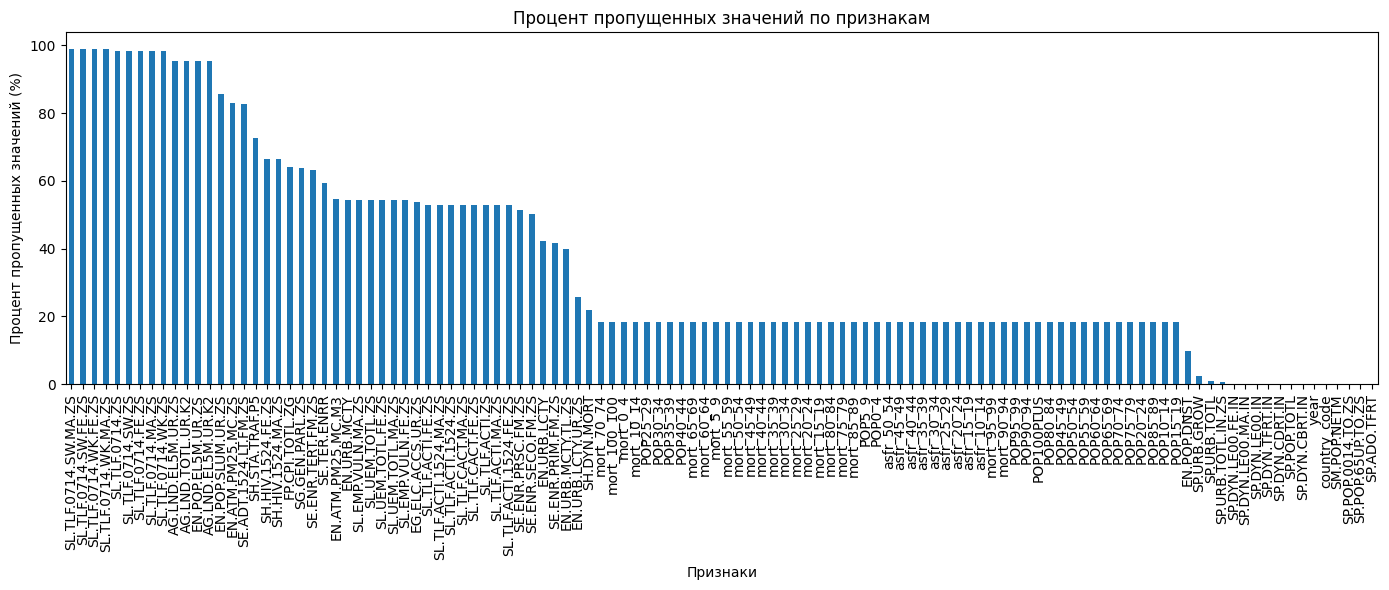

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")

# Процент NaN по столбцам
nan_percent = df.isna().mean() * 100
nan_percent = nan_percent.sort_values(ascending=False)

plt.figure(figsize=(14,6))
nan_percent.plot(kind='bar')
plt.ylabel("Процент пропущенных значений (%)")
plt.xlabel("Признаки")
plt.title("Процент пропущенных значений по признакам")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [156]:
import pandas as pd

df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")

missing_percent = df.isna().mean() * 100

cols_to_drop = missing_percent[missing_percent > 90].index.tolist()

df.drop(columns=cols_to_drop, inplace=True)

df.to_csv("output/basic_with_cohort_unfiltered.csv", index=False)

In [157]:
rename_dict = {
    "EN.POP.DNST": "Pop_density",
    "EN.URB.LCTY": "Urban_pop_largest_city",
    "EN.URB.LCTY.UR.ZS": "Urban_pop_largest_city_percent",
    "EN.URB.MCTY.TL.ZS": "Urban_pop_medium_cities_percent",
    "SH.DYN.MORT": "Crude_death_rate",
    "SM.POP.NETM": "Net_migration",
    "SP.ADO.TFRT": "Adolescent_total_fertility_rate",
    "SP.DYN.CBRT.IN": "Crude_birth_rate",
    "SP.DYN.CDRT.IN": "Crude_death_rate_worldbank",
    "SP.DYN.LE00.FE.IN": "Life_expectancy_female",
    "SP.DYN.LE00.IN": "Life_expectancy_total",
    "SP.DYN.LE00.MA.IN": "Life_expectancy_male",
    "SP.DYN.TFRT.IN": "Total_fertility_rate",
    "SP.POP.0014.TO.ZS": "Population_0_14_percent",
    "SP.POP.65UP.TO.ZS": "Population_65plus_percent",
    "SP.POP.TOTL": "Population_total",
    "SP.URB.GROW": "Urban_population_growth",
    "SP.URB.TOTL": "Urban_population_total",
    "SP.URB.TOTL.IN.ZS": "Urban_population_percent"}
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
df.rename(columns=rename_dict, inplace=True)
if 'POP100PLUS' in df.columns:
    df['POP100PLUS'] = df['POP100PLUS'] * 1000
df.to_csv("output/basic_with_cohort_unfiltered.csv", index = False)

## 3.Препроцессинг данных
население маленьких стран не предсказываем
Много признаков считаются за 1990/2000-2023,
есть проблемы с их применением

In [158]:
import pandas as pd
df_2023 = df_wide[df_wide['year'] == 2023]
countries_keep = df_2023.loc[df_2023['SP.POP.TOTL'] >= 1_000_000, 'country_code'].unique()
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
df = df[df['country_code'].isin(countries_keep)]
df.to_csv("output/basic_with_cohort_unfiltered.csv", index=False)
for col in df.columns:
    if col == 'country_code':
        continue
    missing = df.groupby('country_code')[col].apply(lambda x: x.isna().any()).sum()
    print(col, missing)

year 0
EG.ELC.ACCS.UR.ZS 208
EN.ATM.PM25.MC.M3 208
EN.ATM.PM25.MC.ZS 208
Pop_density 208
EN.POP.SLUM.UR.ZS 208
Urban_pop_largest_city 56
Urban_pop_largest_city_percent 13
EN.URB.MCTY 87
Urban_pop_medium_cities_percent 49
FP.CPI.TOTL.ZG 182
SE.ADT.1524.LT.FM.ZS 208
SE.ENR.PRIM.FM.ZS 208
SE.ENR.PRSC.FM.ZS 208
SE.ENR.SECO.FM.ZS 208
SE.ENR.TERT.FM.ZS 208
SE.TER.ENRR 208
SG.GEN.PARL.ZS 208
Crude_death_rate 102
SH.HIV.1524.FE.ZS 208
SH.HIV.1524.MA.ZS 208
SH.STA.TRAF.P5 208
SL.EMP.VULN.FE.ZS 208
SL.EMP.VULN.MA.ZS 208
SL.TLF.ACTI.1524.FE.ZS 208
SL.TLF.ACTI.1524.MA.ZS 208
SL.TLF.ACTI.1524.ZS 208
SL.TLF.ACTI.FE.ZS 208
SL.TLF.ACTI.MA.ZS 208
SL.TLF.ACTI.ZS 208
SL.TLF.CACT.FE.ZS 208
SL.TLF.CACT.MA.ZS 208
SL.UEM.TOTL.FE.ZS 208
SL.UEM.TOTL.MA.ZS 208
SL.UEM.TOTL.ZS 208
Net_migration 0
Adolescent_total_fertility_rate 0
Crude_birth_rate 1
Crude_death_rate_worldbank 1
Life_expectancy_female 2
Life_expectancy_total 2
Life_expectancy_male 2
Total_fertility_rate 1
Population_0_14_percent 0
Population_65plus

### Линейная интерполяция значений
Интерполируем только те значения у которых NaN<0.33. Целевую переменную не интерполируем

In [ ]:
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
df_clean = df.sort_values(['country_code', 'year'])

num_cols = df_clean.select_dtypes(exclude='object').columns.tolist()
num_cols.remove('Population_total')

na_ratio = df_clean[num_cols].isna().mean()
cols_to_interpolate = na_ratio[na_ratio < 0.33].index.tolist()

df_interpolated = df_clean.copy()
df_interpolated[cols_to_interpolate] = (
    df_interpolated
    .groupby('country_code')[cols_to_interpolate]
    .apply(lambda g: g.interpolate(method='linear').bfill().ffill())
    .reset_index(drop=True)
)

df_interpolated.to_csv("output/basic_with_cohort_unfiltered.csv", index=False)

### Удаление колонок с NaN > 0.33

In [160]:
nan_ratio = df_interpolated.drop(columns=['country_code', 'year']).isna().mean()
cols_to_keep = nan_ratio[nan_ratio < 0.33].index.tolist()
df_clean = df_interpolated[['country_code', 'year'] + cols_to_keep]
df_clean.to_csv("output/basic_with_cohort_filtered.csv", index=False)

Интерполяция не заменяет NAN значения в начале и конце ряда, поэтому NaN значения остаются

In [171]:
import pandas as pd

# Проверка df
nan_df = df_interpolated.isna().sum().sum()
print(f"Общее количество NaN в df: {nan_df}")

nan_df_filtered = df_clean.isna().sum().sum()
print(f"Общее количество NaN в df_filtered: {nan_df_filtered}")

Общее количество NaN в df: 373133
Общее количество NaN в df_filtered: 164574


In [161]:
print(df_clean.columns.size, df_interpolated.columns.size)
print(df_interpolated.head(2))

72 101
  country_code  year  EG.ELC.ACCS.UR.ZS  EN.ATM.PM25.MC.M3  EN.ATM.PM25.MC.ZS  \
0          AFE  1960                NaN                NaN                NaN   
1          AFE  1961                NaN                NaN                NaN   

   Pop_density  EN.POP.SLUM.UR.ZS  Urban_pop_largest_city  \
0    12.036017                NaN                     NaN   
1    12.036017                NaN                     NaN   

   Urban_pop_largest_city_percent  EN.URB.MCTY  \
0                       23.736148          NaN   
1                       23.987197          NaN   

   Urban_pop_medium_cities_percent  FP.CPI.TOTL.ZG  SE.ADT.1524.LT.FM.ZS  \
0                         6.479099             NaN                   NaN   
1                         6.600335             NaN                   NaN   

   SE.ENR.PRIM.FM.ZS  SE.ENR.PRSC.FM.ZS  SE.ENR.SECO.FM.ZS  SE.ENR.TERT.FM.ZS  \
0                NaN                NaN                NaN                NaN   
1                NaN   

### Проверка на России
Данные без Крыма(иначе некорректно скачок 2014-2015 обрабатывался бы). Также проверяем что в POP корректные единицы измерения(люди)

In [162]:
russia_2022 = df[(df['country_code'] == 'RUS') & (df['year'] == 2022)]#единственная колонка pop cohort которой нет в Census
print(russia_2022["Population_total"], "Считаем без Крыма")
print(russia_2022)

10174    144236933.0
Name: Population_total, dtype: float64 Считаем без Крыма
      country_code  year  EG.ELC.ACCS.UR.ZS  EN.ATM.PM25.MC.M3  \
10174          RUS  2022               99.1                NaN   

       EN.ATM.PM25.MC.ZS  Pop_density  EN.POP.SLUM.UR.ZS  \
10174                NaN     8.807357            2.61887   

       Urban_pop_largest_city  Urban_pop_largest_city_percent  EN.URB.MCTY  \
10174              12640818.0                       11.665636   34091812.0   

       Urban_pop_medium_cities_percent  FP.CPI.TOTL.ZG  SE.ADT.1524.LT.FM.ZS  \
10174                         23.63598             NaN                   NaN   

       SE.ENR.PRIM.FM.ZS  SE.ENR.PRSC.FM.ZS  SE.ENR.SECO.FM.ZS  \
10174                NaN                NaN                NaN   

       SE.ENR.TERT.FM.ZS  SE.TER.ENRR  SG.GEN.PARL.ZS  Crude_death_rate  \
10174           1.107013    53.915194       16.222222               4.7   

       SH.HIV.1524.FE.ZS  SH.HIV.1524.MA.ZS  SH.STA.TRAF.P5  \
101

In [163]:
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")

df_period = df[(df['year'] >= 1960) & (df['year'] <= 2023)]

countries_no_population = df_period.groupby('country_code')['Population_total'].apply(lambda x: x.isna().any())

countries_no_population_list = countries_no_population[countries_no_population].index.tolist()

print("Количество стран без данных по популяции:", len(countries_no_population_list))
print("Список стран:", countries_no_population_list)

Количество стран без данных по популяции: 1
Список стран: ['PSE']


Удалим палестину

In [164]:
df = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
df = df[~df['country_code'].isin(countries_no_population_list)]
df.to_csv("output/basic_with_cohort_unfiltered.csv")

In [165]:
df = pd.read_csv("output/basic_with_cohort_filtered.csv")
df = df[~df['country_code'].isin(countries_no_population_list)]
df.to_csv("output/basic_with_cohort_filtered.csv")